In [1]:
# Import of packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
from scipy.stats import skew, kurtosis, jarque_bera

In [2]:
# Helper functions
def max_drawdown(series):
    return (series - series.cummax()).min()

def add_roll_adjusted_changes(x):
    x = x.sort_values(["ID", "Date"]).reset_index(drop=True).copy()
    x["dPrice"] = x.groupby("ID")["Price"].diff()
    x["roll"] = x.groupby("ID")["SymbolKey"].transform(lambda s: s.ne(s.shift()))
    x.loc[x.groupby("ID").cumcount() == 0, "roll"] = False
    x.loc[x["roll"], ["dPrice", "ret"]] = 0.0
    return x

def summarize_distribution(x, value_col, group_cols):
    return (
        x.groupby(group_cols)[value_col]
        .agg(
            mean="mean",
            std="std",
            skew=lambda s: skew(s.dropna()),
            kurtosis=lambda s: kurtosis(s.dropna(), fisher=False),
            jb_stat=lambda s: jarque_bera(s.dropna()).statistic,
            jb_pvalue=lambda s: jarque_bera(s.dropna()).pvalue,
            n="count",
        )
        .reset_index()
    )

def add_target(x):
    x = x.sort_values(["SymbolKey", "Date"]).copy()
    x["dPrice"] = x.groupby("SymbolKey")["Price"].diff()
    x["target_next_dPrice"] = x.groupby("SymbolKey")["dPrice"].shift(-1)
    return x.sort_values("Date").reset_index(drop=True)

def add_price_signals(x):
    x = add_target(x).sort_values(["SymbolKey", "Date"]).copy()
    x["ma_20"] = x.groupby("SymbolKey")["Price"].transform(
        lambda s: s.rolling(20, min_periods=20).mean()
    )
    x["std_20"] = x.groupby("SymbolKey")["Price"].transform(
        lambda s: s.rolling(20, min_periods=20).std(ddof=1)
    )
    x["signal_mom_1d"] = x["dPrice"]
    x["signal_mom_5d"] = x.groupby("SymbolKey")["Price"].diff(5)
    x["signal_ma_dev_20"] = x["Price"] - x["ma_20"]
    x["signal_zscore_20"] = x["signal_ma_dev_20"] / x["std_20"]
    return x.sort_values("Date").reset_index(drop=True)

def add_spread_z_signal(x, ref_price_col):
    x = x.sort_values("Date").reset_index(drop=True).copy()
    x["spread_fq1_y1"] = x["Price"] - x[ref_price_col]
    x["spread_mean_20"] = x["spread_fq1_y1"].rolling(20, min_periods=20).mean()
    x["spread_std_20"] = x["spread_fq1_y1"].rolling(20, min_periods=20).std(ddof=1)
    x["signal_spread_z_20"] = (
        (x["spread_fq1_y1"] - x["spread_mean_20"]) / x["spread_std_20"]
    )
    return x

def add_return_vol_features(x):
    x = x.sort_values(["ID", "Date"]).copy()
    g = x.groupby("ID")
    x["target_next_ret"] = g["ret"].shift(-1)

    def lagged_cum_return(s, window):
        if window == 1:
            return s.shift(1)
        return s.add(1).shift(1).rolling(window, min_periods=window).apply(np.prod, raw=True) - 1

    def lagged_rms_vol(s, window):
        return s.pow(2).shift(1).rolling(window, min_periods=window).mean().pow(0.5)

    def lagged_ewma_mean(s, span):
        return s.shift(1).ewm(span=span, adjust=False, min_periods=span).mean()

    def lagged_ewma_vol(s, span):
        return s.pow(2).shift(1).ewm(span=span, adjust=False, min_periods=span).mean().pow(0.5)

    for w in [1, 5, 20, 60, 120]:
        x[f"ret_{w}d"] = g["ret"].transform(lambda s, w=w: lagged_cum_return(s, w))

    x["ewma_ret_5"] = g["ret"].transform(lambda s: lagged_ewma_mean(s, 5))
    x["ewma_ret_20"] = g["ret"].transform(lambda s: lagged_ewma_mean(s, 20))
    x["ret_5_20_spread"] = x["ret_5d"] - x["ret_20d"]
    x["ret_20_120_spread"] = x["ret_20d"] - x["ret_120d"]
    x["hit_rate_20"] = g["ret"].transform(
        lambda s: s.gt(0).astype(float).shift(1).rolling(20, min_periods=20).mean()
    )

    for w in [5, 20, 60, 120, 250]:
        x[f"vol_{w}d"] = g["ret"].transform(lambda s, w=w: lagged_rms_vol(s, w))

    x["ewma_vol_5"] = g["ret"].transform(lambda s: lagged_ewma_vol(s, 5))
    x["ewma_vol_20"] = g["ret"].transform(lambda s: lagged_ewma_vol(s, 20))
    x["downside_vol_20"] = g["ret"].transform(
        lambda s: s.clip(upper=0).pow(2).shift(1).rolling(20, min_periods=20).mean().pow(0.5)
    )
    x["absret_20"] = g["ret"].transform(
        lambda s: s.abs().shift(1).rolling(20, min_periods=20).mean()
    )
    x["vol_term_spread"] = x["vol_5d"] - x["vol_60d"]

    return x

def fill_by_date_median(x, cols):
    for col in cols:
        x[col] = x[col].fillna(x.groupby("Date")[col].transform("median"))
    return x

def scale_features_minus_one_one(x, cols):
    for col in cols:
        col_min = x.groupby("Date")[col].transform("min")
        col_max = x.groupby("Date")[col].transform("max")
        spread = col_max - col_min
        x[col] = np.where(spread > 0, 2 * (x[col] - col_min) / spread - 1, 0.0)
    return x

def run_sign_strategy(x, signal_col, start, end, direction=1):
    x = x.sort_values("Date").copy()
    x = x[(x["Date"] >= pd.Timestamp(start)) & (x["Date"] <= pd.Timestamp(end))].copy()

    valid = x[signal_col].notna() & x["target_next_dPrice"].notna()
    x["position"] = 0.0
    x.loc[valid, "position"] = direction * np.sign(x.loc[valid, signal_col])

    x["daily_pnl"] = 0.0
    x.loc[valid, "daily_pnl"] = (
        x.loc[valid, "position"]
        * x.loc[valid, "target_next_dPrice"]
        * x.loc[valid, "ContractSize"]
    )
    x["cum_pnl"] = x["daily_pnl"].cumsum()
    return x, x.loc[valid].copy()

def strategy_stats(eval_sample, cum_pnl):
    if eval_sample.empty:
        return {
            "annualized_sharpe": np.nan,
            "t_stat": np.nan,
            "hit_rate": np.nan,
            "cumulative_pnl": 0.0,
            "max_drawdown": max_drawdown(cum_pnl),
        }

    mean_pnl = eval_sample["daily_pnl"].mean()
    std_pnl = eval_sample["daily_pnl"].std(ddof=1)
    return {
        "annualized_sharpe": np.sqrt(252) * mean_pnl / std_pnl if std_pnl > 0 else np.nan,
        "t_stat": mean_pnl / (std_pnl / np.sqrt(len(eval_sample))) if std_pnl > 0 else np.nan,
        "hit_rate": (eval_sample["daily_pnl"] > 0).mean(),
        "cumulative_pnl": eval_sample["daily_pnl"].sum(),
        "max_drawdown": max_drawdown(cum_pnl),
    }

def summarize_pnl_series(name, daily_pnl):
    cum_pnl = daily_pnl.cumsum()
    return {
        "strategy": name,
        "cumulative_pnl": daily_pnl.sum(),
        "mean_daily_pnl": daily_pnl.mean(),
        "std_daily_pnl": daily_pnl.std(ddof=1),
        "worst_day_pnl": daily_pnl.min(),
        "max_drawdown": max_drawdown(cum_pnl),
    }

def build_futures_pnl(contract_df, sign, start, end):
    x = add_target(contract_df)
    x = x[(x["Date"] >= pd.Timestamp(start)) & (x["Date"] <= pd.Timestamp(end))].copy()
    x["daily_pnl"] = sign * x["dPrice"] * x["ContractSize"]
    x["daily_pnl"] = x["daily_pnl"].fillna(0.0)
    return x[["Date", "daily_pnl"]].sort_values("Date").reset_index(drop=True)

def format_date_axis(ax, start, end, freq="4MS"):
    start = pd.Timestamp(start)
    end = pd.Timestamp(end)
    ticks = list(pd.date_range(start, end, freq=freq))
    if not ticks or ticks[-1] != end:
        ticks.append(end)
    ax.set_xlim(start, end)
    ax.set_xticks(ticks)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

## Question 1.1

In [3]:
# Load data
from pathlib import Path

possible_files = ["data.csv", "GRA65612_data.csv"]
data_path = None

for fname in possible_files:
    if Path(fname).exists():
        data_path = fname
        break

if data_path is None:
    raise FileNotFoundError("Could not find data.csv or GRA65612_data.csv in the working directory.")

df = pd.read_csv(data_path)
df["Date"] = pd.to_datetime(df["Date"])
df["ret"] = df["ret"].replace(-99, np.nan)

# Selected contracts
contracts = ["EEXFM1", "EEXFM2", "EEXFQ1", "EEXY1", "ENOFM1", "ENOY1"]

# Filter and construct roll-adjusted price changes
df6 = add_roll_adjusted_changes(df[df["ID"].isin(contracts)].copy())
df_changes = df6[df6["dPrice"].notna()].copy()

print(df_changes[["Date", "ID", "SymbolKey", "Price", "dPrice", "roll"]].head(10))
print(df_changes["dPrice"].isna().sum())

         Date      ID         SymbolKey  Price  dPrice   roll
1  2006-01-03  EEXFM1  EEX DEB FEB-2006  68.75   -3.75  False
2  2006-01-04  EEXFM1  EEX DEB FEB-2006  68.75    0.00  False
3  2006-01-05  EEXFM1  EEX DEB FEB-2006  67.75   -1.00  False
4  2006-01-06  EEXFM1  EEX DEB FEB-2006  69.40    1.65  False
5  2006-01-09  EEXFM1  EEX DEB FEB-2006  67.15   -2.25  False
6  2006-01-10  EEXFM1  EEX DEB FEB-2006  67.55    0.40  False
7  2006-01-11  EEXFM1  EEX DEB FEB-2006  68.35    0.80  False
8  2006-01-12  EEXFM1  EEX DEB FEB-2006  65.40   -2.95  False
9  2006-01-13  EEXFM1  EEX DEB FEB-2006  63.95   -1.45  False
10 2006-01-16  EEXFM1  EEX DEB FEB-2006  62.50   -1.45  False
0


## Question 1.2

In [4]:
# Keep only the required periods
df_stats = df_changes[
    ((df_changes["Date"].dt.year >= 2017) & (df_changes["Date"].dt.year <= 2020)) |
    ((df_changes["Date"].dt.year >= 2023) & (df_changes["Date"].dt.year <= 2025))
].copy()

# Period label
df_stats["period"] = np.where(
    df_stats["Date"].dt.year <= 2020,
    "2017--2020",
    "2023--2025"
)

# Summary table
summary = summarize_distribution(df_stats, "dPrice", ["period", "ID"])

# Round for display
summary_display = summary.copy()
for col in ["mean", "std", "skew", "kurtosis"]:
    summary_display[col] = summary_display[col].round(4)

print(summary_display[["period", "ID", "mean", "std", "skew", "kurtosis", "n"]])

        period      ID    mean     std    skew  kurtosis     n
0   2017--2020  EEXFM1 -0.0192  0.9865  0.2860    8.8810  1016
1   2017--2020  EEXFM2  0.0043  0.8045  0.4166    6.4738  1016
2   2017--2020  EEXFQ1 -0.0087  0.7624  0.3550    6.2322   987
3   2017--2020   EEXY1  0.0199  0.6310  0.1348    4.9629  1011
4   2017--2020  ENOFM1 -0.0176  0.9947  0.1888    7.2182  1014
5   2017--2020   ENOY1  0.0069  0.5820  0.0344    5.2842  1004
6   2023--2025  EEXFM1 -0.2049  3.4956 -0.0857    8.4730   766
7   2023--2025  EEXFM2 -0.2519  3.2888 -0.1093    8.8904   766
8   2023--2025  EEXFQ1 -0.2125  3.2847 -0.2946    8.9168   742
9   2023--2025   EEXY1 -0.1560  3.0308 -0.9263   13.3598   760
10  2023--2025  ENOFM1 -0.1384  2.9337 -0.9106   14.6556   763
11  2023--2025   ENOY1 -0.0491  1.2904 -1.3769   14.8894   756


## Question 1.3

In [5]:
# Use only the EEXFM1 return series
df_vol = df.loc[df["ID"] == "EEXFM1", ["Date", "ret"]].sort_values("Date").copy()

# Candidate rolling volatility estimators
windows = [20, 60, 125, 250]
for w in windows:
    df_vol[f"vol_{w}"] = df_vol["ret"].rolling(w, min_periods=max(10, w // 2)).std(ddof=1)
    df_vol[f"forecast_{w}"] = df_vol[f"vol_{w}"].shift(1)

# Keep only the period required in Q1.3
eval_df = df_vol[df_vol["Date"] >= "2017-01-01"].assign(
    abs_ret=lambda x: x["ret"].abs(),
    sq_ret=lambda x: x["ret"] ** 2,
)

# Compare the candidate estimators
rows = []
for w in windows:
    tmp = eval_df[[f"forecast_{w}", "abs_ret", "sq_ret"]].dropna()
    rows.append({
        "window": w,
        "MAE_abs_ret": (tmp[f"forecast_{w}"] - tmp["abs_ret"]).abs().mean(),
        "RMSE_abs_ret": np.sqrt(((tmp[f"forecast_{w}"] - tmp["abs_ret"]) ** 2).mean()),
        "corr_abs_ret": tmp[f"forecast_{w}"].corr(tmp["abs_ret"]),
        "MSE_sq_ret": ((tmp[f"forecast_{w}"] ** 2 - tmp["sq_ret"]) ** 2).mean()
    })

# Summary table
evaluation = pd.DataFrame(rows).round(6)
evaluation

,window,MAE_abs_ret,RMSE_abs_ret,corr_abs_ret,MSE_sq_ret
0,20,0.020021,0.030580,0.440864,0.000053
1,60,0.020863,0.030999,0.413968,0.000051
2,125,0.021752,0.031756,0.371332,0.000052
3,250,0.022160,0.031857,0.359240,0.000053


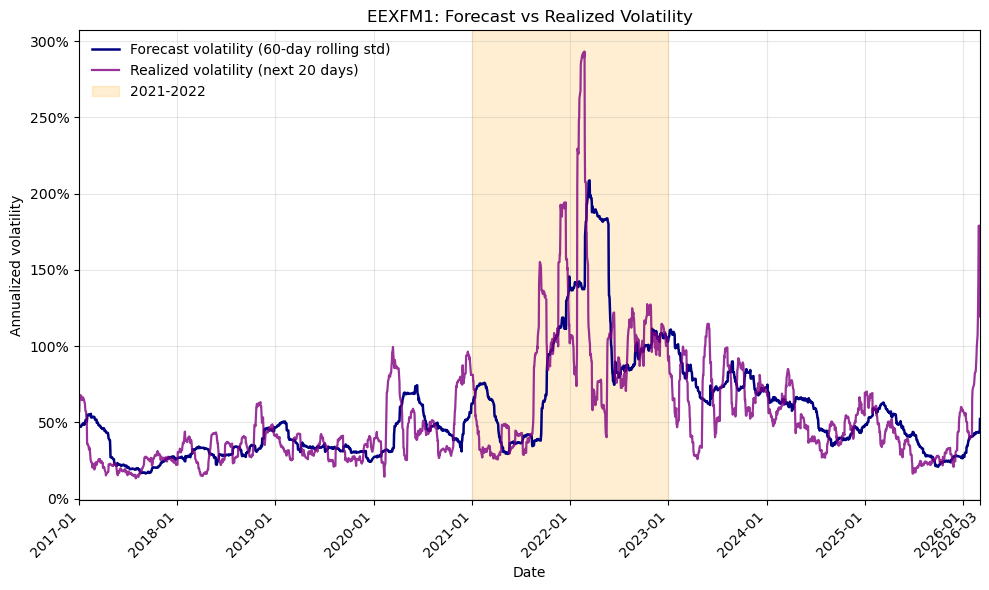

In [6]:
# Chosen estimator: 60-day rolling volatility
chosen_window = 60
df_vol["vol_forecast_annual"] = df_vol[f"forecast_{chosen_window}"] * np.sqrt(252)

# Forward realized volatility proxy:
# annualized sqrt of average squared returns over the next 20 trading days
h = 20
future_sq = pd.concat(
    [df_vol["ret"].shift(-i) ** 2 for i in range(1, h + 1)],
    axis=1
)

df_vol["realized_vol_20d"] = np.sqrt(future_sq.mean(axis=1) * 252)

# Keep only the plotted sample
plot_df = df_vol[df_vol["Date"] >= "2017-01-01"].copy()

# Plot volatility from 2017 onwards
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    plot_df["Date"],
    plot_df["vol_forecast_annual"],
    color="navy",
    lw=1.8,
    label="Forecast volatility (60-day rolling std)"
)

ax.plot(
    plot_df["Date"],
    plot_df["realized_vol_20d"],
    color="purple",
    lw=1.6,
    alpha=0.8,
    label="Realized volatility (next 20 days)"
)

ax.axvspan(
    pd.Timestamp("2021-01-01"),
    pd.Timestamp("2022-12-31"),
    color="orange",
    alpha=0.18,
    label="2021-2022"
)

ax.set_title("EEXFM1: Forecast vs Realized Volatility")
ax.set_xlabel("Date")
ax.set_ylabel("Annualized volatility")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
format_date_axis(ax, "2017-01-01", plot_df["Date"].max(), freq="YS")
ax.grid(alpha=0.3)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## Question 1.4

,strategy,cumulative_pnl,mean_daily_pnl,std_daily_pnl,worst_day_pnl,max_drawdown
0,Short FM1,342708.86,149.33,6682.19,-75210.96,-353407.27
1,FM1-FM2 spread,136290.88,59.39,2689.08,-43849.10,-127595.50


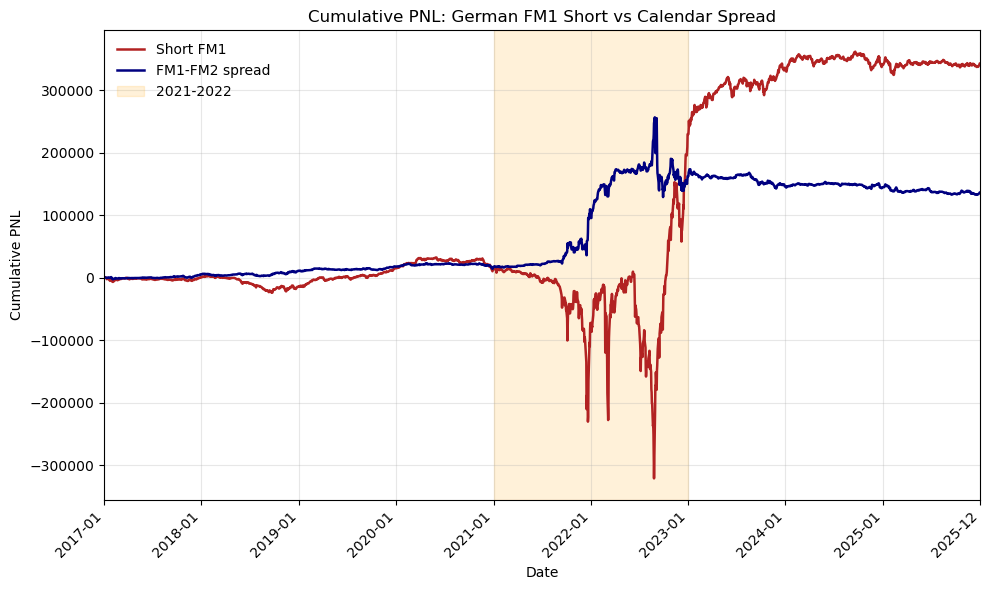

In [7]:
# Keep only the period required in Q1.4
start_date = "2017-01-01"
end_date = "2025-12-31"

# Daily PNL for the outright short and the calendar spread
fm1_short = build_futures_pnl(df[df["ID"] == "EEXFM1"].copy(), -1, start_date, end_date)
fm1_short = fm1_short.rename(columns={"daily_pnl": "outright_short"})
fm2_long = build_futures_pnl(df[df["ID"] == "EEXFM2"].copy(), 1, start_date, end_date)
fm2_long = fm2_long.rename(columns={"daily_pnl": "fm2_long"})

pnl_df = fm1_short.merge(fm2_long, on="Date", how="inner")
pnl_df = pnl_df.sort_values("Date").reset_index(drop=True)
pnl_df["calendar_spread"] = pnl_df["outright_short"] + pnl_df["fm2_long"]
pnl_df["cum_outright_short"] = pnl_df["outright_short"].cumsum()
pnl_df["cum_calendar_spread"] = pnl_df["calendar_spread"].cumsum()

# Summary table
summary = pd.DataFrame([
    summarize_pnl_series("Short FM1", pnl_df["outright_short"]),
    summarize_pnl_series("FM1-FM2 spread", pnl_df["calendar_spread"]),
]).round(2)

display(summary)

# Plot both cumulative PNL series
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(pnl_df["Date"], pnl_df["cum_outright_short"], lw=1.8, color="firebrick", label="Short FM1")
ax.plot(pnl_df["Date"], pnl_df["cum_calendar_spread"], lw=1.8, color="navy", label="FM1-FM2 spread")
ax.axvspan(pd.Timestamp("2021-01-01"), pd.Timestamp("2022-12-31"), color="orange", alpha=0.15, label="2021-2022")
ax.set_title("Cumulative PNL: German FM1 Short vs Calendar Spread")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative PNL")
format_date_axis(ax, start_date, end_date, freq="YS")
ax.grid(alpha=0.3)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## Question 2.1

In [8]:
# Keep only the period required in Q2.1
q21_start = "2017-01-01"
q21_end = "2020-12-31"

# Use EEXFQ1 as the traded contract
q21 = df[(df["ID"] == "EEXFQ1") & (df["Date"] >= q21_start) & (df["Date"] <= q21_end)].copy()

# Merge the Y1 contract for the spread signal
y1 = df[(df["ID"] == "EEXY1") & (df["Date"] >= q21_start) & (df["Date"] <= q21_end)][["Date", "Price"]].copy()
y1 = y1.rename(columns={"Price": "Price_Y1"})

q21 = q21.merge(y1, on="Date", how="left")
q21 = add_price_signals(q21)
q21 = add_spread_z_signal(q21, "Price_Y1")

# Signal names and hypotheses
signal_info = {
    "signal_mom_1d": {"label": "1-day momentum", "hypothesis": "Trend"},
    "signal_mom_5d": {"label": "5-day momentum", "hypothesis": "Trend"},
    "signal_ma_dev_20": {"label": "20-day MA deviation", "hypothesis": "Price deviation"},
    "signal_zscore_20": {"label": "20-day z-score", "hypothesis": "Standardized price deviation"},
    "signal_spread_z_20": {"label": "FQ1-Y1 spread z-score", "hypothesis": "Relative-value deviation"},
}

signal_cols = [
    "signal_mom_1d",
    "signal_mom_5d",
    "signal_ma_dev_20",
    "signal_zscore_20",
    "signal_spread_z_20",
]

# Rank the five signals in 2017-2020
signal_direction_q21 = {}
ranking_rows = []

for col in signal_cols:
    tmp = q21[[col, "target_next_dPrice"]].dropna().copy()
    beta_hat = tmp[col].cov(tmp["target_next_dPrice"]) / tmp[col].var()
    direction = 1 if beta_hat > 0 else -1
    signal_direction_q21[col] = direction

    bt, eval_sample = run_sign_strategy(
        q21[["Date", "ContractSize", "target_next_dPrice", col]],
        col,
        q21_start,
        q21_end,
        direction,
    )
    stats = strategy_stats(eval_sample, bt["cum_pnl"])

    ranking_rows.append({
        "signal_col": col,
        "signal": signal_info[col]["label"],
        "hypothesis": signal_info[col]["hypothesis"],
        "trade_if_signal_positive": "Long" if direction > 0 else "Short",
        "beta_hat": beta_hat,
        **stats,
    })

signal_ranking_q21 = pd.DataFrame(ranking_rows)
signal_ranking_q21 = signal_ranking_q21.sort_values(
    ["annualized_sharpe", "t_stat", "cumulative_pnl"],
    ascending=False,
).reset_index(drop=True)

# Keep the two best signals for Q2.2
best_two_signal_cols_q22 = signal_ranking_q21.loc[:1, "signal_col"].tolist()

# Summary table
signal_summary_q21 = signal_ranking_q21[[
    "signal",
    "hypothesis",
    "trade_if_signal_positive",
    "beta_hat",
    "annualized_sharpe",
    "t_stat",
    "hit_rate",
    "cumulative_pnl",
]].round(4)

signal_summary_q21

,signal,hypothesis,trade_if_signal_positive,beta_hat,annualized_sharpe,t_stat,hit_rate,cumulative_pnl
0,1-day momentum,Trend,Long,0.0933,1.5270,2.9726,0.5183,154124.79
1,FQ1-Y1 spread z-score,Relative-value deviation,Long,0.0360,1.4178,2.7557,0.5305,142962.33
2,20-day MA deviation,Price deviation,Long,0.0240,1.1015,1.7921,0.5292,78543.47
3,20-day z-score,Standardized price deviation,Long,0.0482,1.1015,1.7921,0.5292,78543.47
4,5-day momentum,Trend,Long,0.0061,0.1399,0.2631,0.5017,13193.71


## Question 2.2

,signal,hypothesis,trade_if_signal_positive,annualized_sharpe,t_stat,hit_rate,cumulative_pnl,max_drawdown
0,1-day momentum,Trend,Long,0.3179,0.4979,0.4951,75734.83,-89790.09
1,FQ1-Y1 spread z-score,Relative-value deviation,Long,0.4825,0.7617,0.5032,116741.14,-117489.92


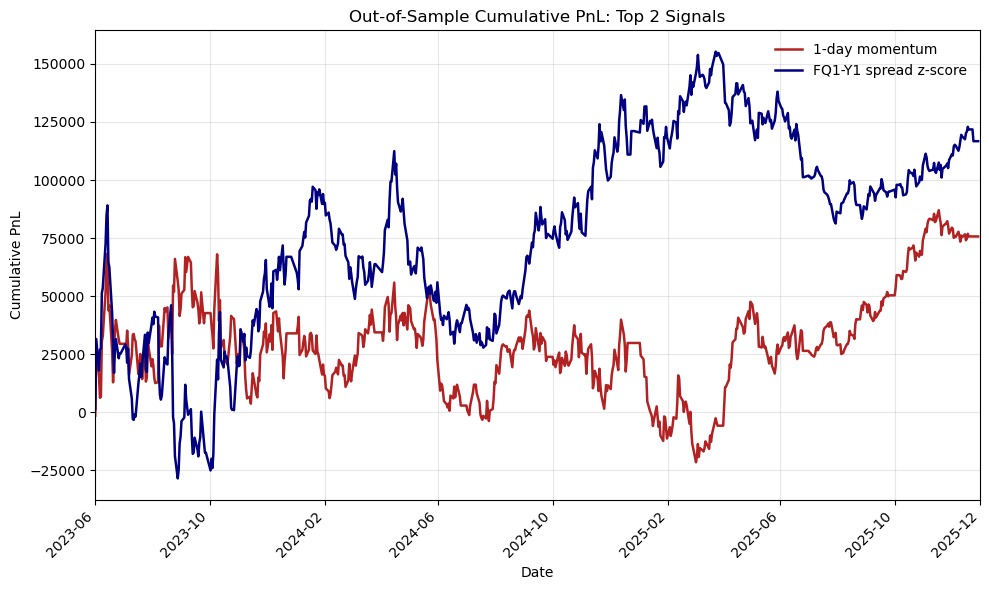

In [10]:
# Keep only the out-of-sample period required in Q2.2
q22_start = "2023-06-01"
q22_end = "2025-12-31"

# Use the same contract and build the signals up to the test end date
q22 = df[(df["ID"] == "EEXFQ1") & (df["Date"] <= q22_end)].copy()
y1_q22 = df[df["ID"] == "EEXY1"][['Date', 'Price']].copy()
y1_q22 = y1_q22[y1_q22["Date"] <= q22_end].rename(columns={"Price": "Price_Y1"})

q22 = q22.merge(y1_q22, on="Date", how="left")
q22 = add_price_signals(q22)
q22 = add_spread_z_signal(q22, "Price_Y1")

# Test the two best signals selected on the training set
oos_rows = []
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["firebrick", "navy"]

for color, col in zip(colors, best_two_signal_cols_q22):
    bt, eval_sample = run_sign_strategy(
        q22[["Date", "ContractSize", "target_next_dPrice", col]],
        col,
        q22_start,
        q22_end,
        signal_direction_q21[col],
    )
    stats = strategy_stats(eval_sample, bt["cum_pnl"])

    oos_rows.append({
        "signal": signal_info[col]["label"],
        "hypothesis": signal_info[col]["hypothesis"],
        "trade_if_signal_positive": "Long" if signal_direction_q21[col] > 0 else "Short",
        **stats,
    })

    ax.plot(bt["Date"], bt["cum_pnl"], lw=1.8, color=color, label=signal_info[col]["label"])

# Summary table
signal_test_q22 = pd.DataFrame(oos_rows).round(4)
display(signal_test_q22)

# Plot both cumulative PnL series
ax.set_title("Out-of-Sample Cumulative PnL: Top 2 Signals")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative PnL")
format_date_axis(ax, q22_start, q22_end)
ax.grid(alpha=0.3)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## Question 2.3

,contract,annualized_sharpe,t_stat,hit_rate,cumulative_pnl,max_drawdown
0,ENOY1,2.2797,3.9329,0.5027,1180291.20,-113313.60
1,ENOFM1,2.0057,3.3213,0.5239,179302.72,-32212.32
2,EEXY1,1.3153,2.2751,0.4894,1661668.08,-338711.04
3,EEXFM2,0.5640,0.9359,0.5144,61508.59,-27562.97
4,EEXFM1,-0.0908,-0.1507,0.4986,-10170.62,-56773.42


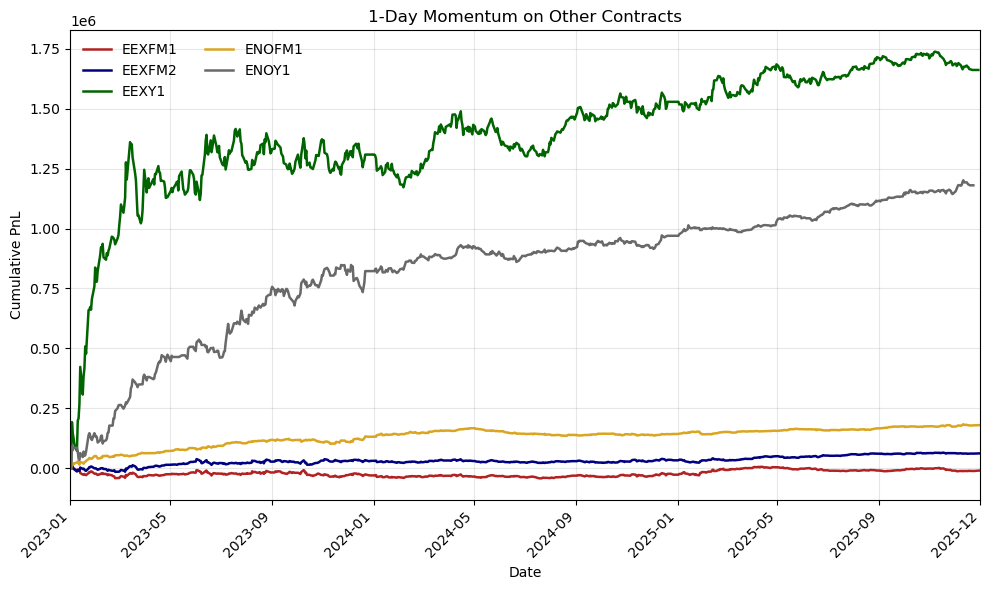

In [11]:
# Test 1-day momentum on the other five contracts in 2023-2025
q23_start = "2023-01-01"
q23_end = "2025-12-31"
q23_contracts = ["EEXFM1", "EEXFM2", "EEXY1", "ENOFM1", "ENOY1"]

# Test the same signal and same trading rule on each contract
q23_rows = []
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["firebrick", "navy", "darkgreen", "goldenrod", "dimgray"]

for color, contract_id in zip(colors, q23_contracts):
    tmp = add_target(df[df["ID"] == contract_id].copy())
    bt, eval_sample = run_sign_strategy(
        tmp[["Date", "ContractSize", "target_next_dPrice", "dPrice"]],
        "dPrice",
        q23_start,
        q23_end,
    )
    stats = strategy_stats(eval_sample, bt["cum_pnl"])

    q23_rows.append({"contract": contract_id, **stats})
    ax.plot(bt["Date"], bt["cum_pnl"], lw=1.8, color=color, label=contract_id)

# Summary table
q23_results = pd.DataFrame(q23_rows)
q23_results = q23_results.sort_values("annualized_sharpe", ascending=False).reset_index(drop=True)
display(q23_results.round(4))

# Plot cumulative PnL for all five contracts
ax.set_title("1-Day Momentum on Other Contracts")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative PnL")
format_date_axis(ax, q23_start, q23_end)
ax.grid(alpha=0.3)
ax.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.show()

## Question 2.4

In [12]:
# Test EEXY1 with 1-day momentum in the available 2026 sample
q24_start = pd.Timestamp("2026-01-01")
q24 = add_target(df[df["ID"] == "EEXY1"].copy())
q24_end = q24.loc[q24["Date"] >= q24_start, "Date"].max()

q24_bt, q24_eval = run_sign_strategy(
    q24[["Date", "ContractSize", "target_next_dPrice", "dPrice"]],
    "dPrice",
    q24_start,
    q24_end,
)
q24_stats = strategy_stats(q24_eval, q24_bt["cum_pnl"])

q24_results = pd.DataFrame([{
    "contract": "EEXY1",
    "signal": "1-day momentum",
    "start_date": q24_start.date(),
    "end_date": q24_end.date(),
    **q24_stats,
}]).round(4)

display(q24_results)

,contract,signal,start_date,end_date,annualized_sharpe,t_stat,hit_rate,cumulative_pnl,max_drawdown
0,EEXY1,1-day momentum,2026-01-01,2026-03-04,1.755,0.7165,0.5238,59743.2,-54750.0


## Question 3.1

,feature,group,lookback_days,construction
0,ret_1d,Past return,1,Lagged 1-day return
1,ret_5d,Past return,5,Lagged cumulative 5-day return
2,ret_20d,Past return,20,Lagged cumulative 20-day return
3,ret_60d,Past return,60,Lagged cumulative 60-day return
4,ret_120d,Past return,120,Lagged cumulative 120-day return
5,ewma_ret_5,Past return,5,Lagged EWMA mean return
6,ewma_ret_20,Past return,20,Lagged EWMA mean return
7,ret_5_20_spread,Past return,5 vs 20,Short-minus-medium cumulative return
8,ret_20_120_spread,Past return,20 vs 120,Medium-minus-long cumulative return
9,hit_rate_20,Past return,20,Lagged share of positive return days


,sample,start_date,end_date,n_obs,n_dates,n_contracts,n_features,missing_before_fill,missing_after_fill,rank_X,cond_X,max_abs_corr
0,train,2017-01-02,2020-12-30,6048,1016,6,20,0,0,20,21.93,0.9689
1,validation,2023-01-02,2024-12-31,3038,511,6,20,0,0,20,26.87,0.9803
2,test,2025-01-02,2025-12-31,1515,255,6,20,0,0,20,45.20,0.9916


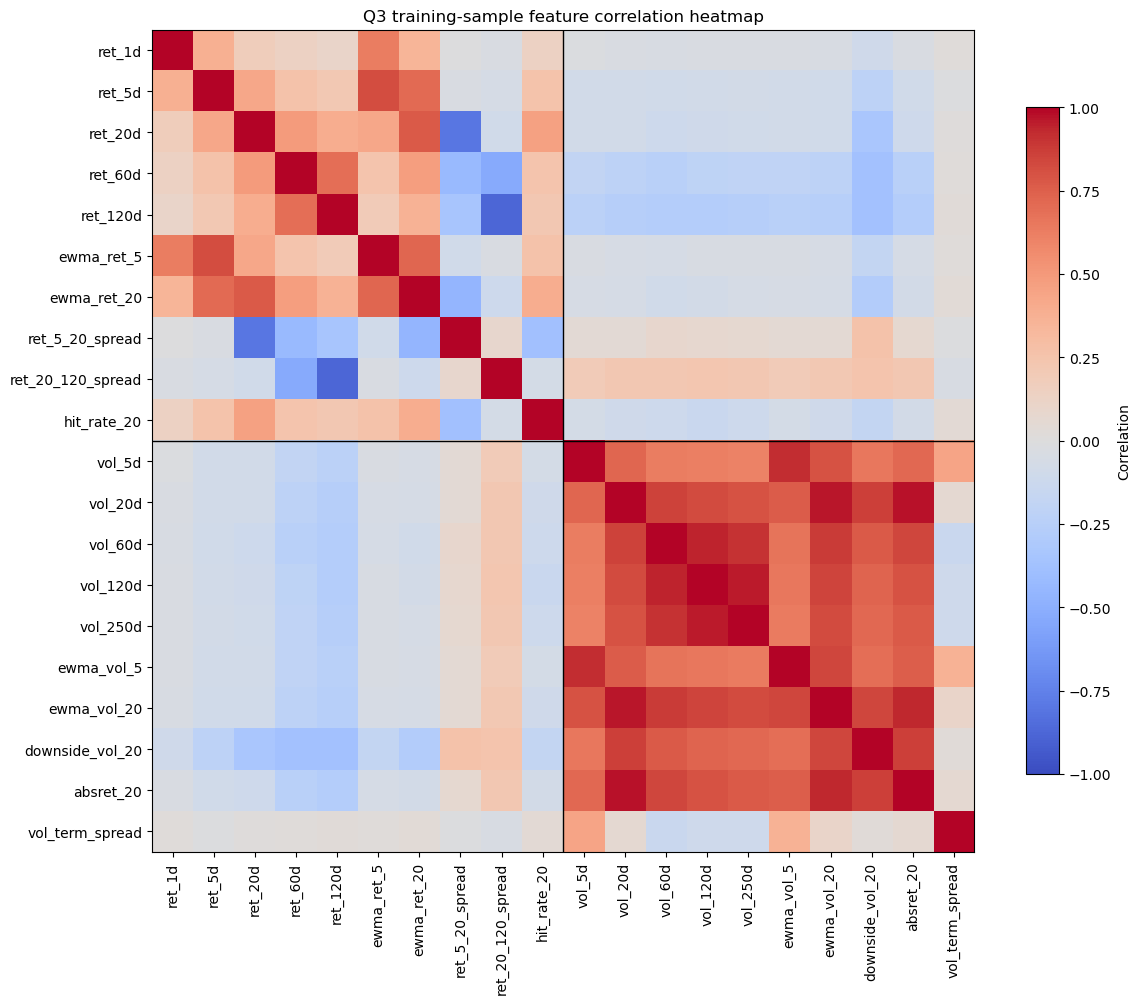

,contract,date,ret_5d_feature,ret_5d_manual,vol_5d_feature,vol_5d_manual,target_feature,target_manual
0,EEXY1,2017-01-02,0.062171,0.062171,0.015535,0.015535,-0.027261,-0.027261


Target variable: target_next_ret.
Predictor matrix X uses 20 features: 10 return signals and 10 volatility signals.


In [13]:
# Use next-day returns because returns are scale-free across contracts

# Build the contract-date panel for the same six contracts as in Q1 and Q2
q31 = add_roll_adjusted_changes(df[df["ID"].isin(contracts)].copy())
q31["ret"] = q31["ret"].fillna(0.0)
q31 = add_return_vol_features(q31)

# Predictor lists: 10 return-derived signals and 10 volatility-derived signals
q31_ret_cols = [
    "ret_1d",
    "ret_5d",
    "ret_20d",
    "ret_60d",
    "ret_120d",
    "ewma_ret_5",
    "ewma_ret_20",
    "ret_5_20_spread",
    "ret_20_120_spread",
    "hit_rate_20",
]
q31_vol_cols = [
    "vol_5d",
    "vol_20d",
    "vol_60d",
    "vol_120d",
    "vol_250d",
    "ewma_vol_5",
    "ewma_vol_20",
    "downside_vol_20",
    "absret_20",
    "vol_term_spread",
]
feature_cols_q3 = q31_ret_cols + q31_vol_cols
target_col_q3 = "target_next_ret"

# Split the sample by time and leave 2021-2022 out between training and validation
q31["sample"] = "other"
q31.loc[q31["Date"].between("2017-01-01", "2020-12-31"), "sample"] = "train"
q31.loc[q31["Date"].between("2023-01-01", "2024-12-31"), "sample"] = "validation"
q31.loc[q31["Date"].between("2025-01-01", "2025-12-31"), "sample"] = "test"
q31_raw = q31.copy()

# Impute missing features by date and normalize each feature to [-1, 1] in the cross-section
q31["missing_features_before"] = q31[feature_cols_q3].isna().sum(axis=1)
q31 = fill_by_date_median(q31, feature_cols_q3)
q31 = scale_features_minus_one_one(q31, feature_cols_q3)
q31[feature_cols_q3] = q31[feature_cols_q3].fillna(0.0)

# Keep only rows with a valid target in the train/validation/test periods
q3_panel = q31[q31["sample"].isin(["train", "validation", "test"]) & q31[target_col_q3].notna()].copy()
q3_panel["sample"] = pd.Categorical(q3_panel["sample"], ["train", "validation", "test"], ordered=True)
q3_panel = q3_panel.sort_values(["Date", "ID"]).reset_index(drop=True)

q3_train = q3_panel[q3_panel["sample"] == "train"].copy()
q3_validation = q3_panel[q3_panel["sample"] == "validation"].copy()
q3_test = q3_panel[q3_panel["sample"] == "test"].copy()

X_train_q3 = q3_train[feature_cols_q3].to_numpy()
y_train_q3 = q3_train[target_col_q3].to_numpy()
X_validation_q3 = q3_validation[feature_cols_q3].to_numpy()
y_validation_q3 = q3_validation[target_col_q3].to_numpy()
X_test_q3 = q3_test[feature_cols_q3].to_numpy()
y_test_q3 = q3_test[target_col_q3].to_numpy()

# Signal summary
signal_summary_q31 = pd.DataFrame([
    {"feature": "ret_1d", "group": "Past return", "lookback_days": 1, "construction": "Lagged 1-day return"},
    {"feature": "ret_5d", "group": "Past return", "lookback_days": 5, "construction": "Lagged cumulative 5-day return"},
    {"feature": "ret_20d", "group": "Past return", "lookback_days": 20, "construction": "Lagged cumulative 20-day return"},
    {"feature": "ret_60d", "group": "Past return", "lookback_days": 60, "construction": "Lagged cumulative 60-day return"},
    {"feature": "ret_120d", "group": "Past return", "lookback_days": 120, "construction": "Lagged cumulative 120-day return"},
    {"feature": "ewma_ret_5", "group": "Past return", "lookback_days": 5, "construction": "Lagged EWMA mean return"},
    {"feature": "ewma_ret_20", "group": "Past return", "lookback_days": 20, "construction": "Lagged EWMA mean return"},
    {"feature": "ret_5_20_spread", "group": "Past return", "lookback_days": "5 vs 20", "construction": "Short-minus-medium cumulative return"},
    {"feature": "ret_20_120_spread", "group": "Past return", "lookback_days": "20 vs 120", "construction": "Medium-minus-long cumulative return"},
    {"feature": "hit_rate_20", "group": "Past return", "lookback_days": 20, "construction": "Lagged share of positive return days"},
    {"feature": "vol_5d", "group": "Past volatility", "lookback_days": 5, "construction": "Lagged RMS volatility"},
    {"feature": "vol_20d", "group": "Past volatility", "lookback_days": 20, "construction": "Lagged RMS volatility"},
    {"feature": "vol_60d", "group": "Past volatility", "lookback_days": 60, "construction": "Lagged RMS volatility"},
    {"feature": "vol_120d", "group": "Past volatility", "lookback_days": 120, "construction": "Lagged RMS volatility"},
    {"feature": "vol_250d", "group": "Past volatility", "lookback_days": 250, "construction": "Lagged RMS volatility"},
    {"feature": "ewma_vol_5", "group": "Past volatility", "lookback_days": 5, "construction": "Lagged EWMA volatility"},
    {"feature": "ewma_vol_20", "group": "Past volatility", "lookback_days": 20, "construction": "Lagged EWMA volatility"},
    {"feature": "downside_vol_20", "group": "Past volatility", "lookback_days": 20, "construction": "Lagged RMS volatility of negative returns"},
    {"feature": "absret_20", "group": "Past volatility", "lookback_days": 20, "construction": "Lagged mean absolute return"},
    {"feature": "vol_term_spread", "group": "Past volatility", "lookback_days": "5 vs 60", "construction": "Short-minus-long volatility term spread"},
])
display(signal_summary_q31)

# Sample summary and X diagnostics
diag_rows = []
for sample_name, sample_df in [("train", q3_train), ("validation", q3_validation), ("test", q3_test)]:
    X = sample_df[feature_cols_q3].to_numpy()
    corr = sample_df[feature_cols_q3].corr().abs()
    np.fill_diagonal(corr.values, np.nan)

    diag_rows.append({
        "sample": sample_name,
        "start_date": sample_df["Date"].min().date(),
        "end_date": sample_df["Date"].max().date(),
        "n_obs": len(sample_df),
        "n_dates": sample_df["Date"].nunique(),
        "n_contracts": sample_df["ID"].nunique(),
        "n_features": len(feature_cols_q3),
        "missing_before_fill": int(sample_df["missing_features_before"].sum()),
        "missing_after_fill": int(sample_df[feature_cols_q3].isna().sum().sum()),
        "rank_X": int(np.linalg.matrix_rank(X)),
        "cond_X": np.linalg.cond(X),
        "max_abs_corr": np.nanmax(corr.to_numpy()),
    })

q31_diagnostics = pd.DataFrame(diag_rows)
display(q31_diagnostics.round({"cond_X": 2, "max_abs_corr": 4}))

# Correlation heatmap for the training design matrix
corr_train_q31 = q3_train[feature_cols_q3].corr()
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr_train_q31, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(feature_cols_q3)))
ax.set_yticks(range(len(feature_cols_q3)))
ax.set_xticklabels(feature_cols_q3, rotation=90)
ax.set_yticklabels(feature_cols_q3)
ax.axhline(len(q31_ret_cols) - 0.5, color="black", linewidth=1)
ax.axvline(len(q31_ret_cols) - 0.5, color="black", linewidth=1)
ax.set_title("Q3 training-sample feature correlation heatmap")
fig.colorbar(im, ax=ax, shrink=0.8, label="Correlation")
plt.tight_layout()
plt.show()

# Timing sanity check on one raw contract-date observation
timing_contract_q31 = "EEXY1"
timing_row_q31 = q31_raw[
    (q31_raw["ID"] == timing_contract_q31)
    & (q31_raw["sample"] == "train")
    & q31_raw["ret_5d"].notna()
    & q31_raw["vol_5d"].notna()
    & q31_raw[target_col_q3].notna()
][["Date"]].iloc[0]
timing_date_q31 = timing_row_q31["Date"]
timing_panel_q31 = q31_raw[q31_raw["ID"] == timing_contract_q31].sort_values("Date").reset_index(drop=True)
timing_idx_q31 = timing_panel_q31.index[timing_panel_q31["Date"] == timing_date_q31][0]
past_ret_5d_q31 = timing_panel_q31.loc[timing_idx_q31 - 5:timing_idx_q31 - 1, "ret"].to_numpy()

q31_timing_check = pd.DataFrame([{
    "contract": timing_contract_q31,
    "date": timing_date_q31.date(),
    "ret_5d_feature": timing_panel_q31.loc[timing_idx_q31, "ret_5d"],
    "ret_5d_manual": np.prod(1 + past_ret_5d_q31) - 1,
    "vol_5d_feature": timing_panel_q31.loc[timing_idx_q31, "vol_5d"],
    "vol_5d_manual": np.sqrt(np.mean(np.square(past_ret_5d_q31))),
    "target_feature": timing_panel_q31.loc[timing_idx_q31, target_col_q3],
    "target_manual": timing_panel_q31.loc[timing_idx_q31 + 1, "ret"],
}]).round(6)
display(q31_timing_check)

print(f"Target variable: {target_col_q3}.")
print(f"Predictor matrix X uses {len(feature_cols_q3)} features: {len(q31_ret_cols)} return signals and {len(q31_vol_cols)} volatility signals.")


## Question 3.2

In [14]:
def ridge_fit_closed_form(X, y, lam):
    Xb = np.column_stack([np.ones(len(X)), X])
    penalty = np.eye(Xb.shape[1])
    penalty[0, 0] = 0.0
    beta = np.linalg.solve(Xb.T @ Xb + lam * penalty, Xb.T @ y)
    return beta

def ridge_predict(X, beta):
    Xb = np.column_stack([np.ones(len(X)), X])
    return Xb @ beta

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def gkx_r2(y_true, y_pred):
    denom = np.sum(y_true ** 2)
    return 1.0 - np.sum((y_true - y_pred) ** 2) / denom if denom > 0 else np.nan

lambda_grid_q32 = np.concatenate(([0.0], np.logspace(-6, 4, 41)))
ridge_grid_rows_q32 = []

for lam in lambda_grid_q32:
    beta = ridge_fit_closed_form(X_train_q3, y_train_q3, lam)
    validation_pred = ridge_predict(X_validation_q3, beta)

    ridge_grid_rows_q32.append({
        "lambda": lam,
        "validation_mse": mse(y_validation_q3, validation_pred),
    })

ridge_grid_q32 = pd.DataFrame(ridge_grid_rows_q32)
best_row_q32 = ridge_grid_q32.loc[ridge_grid_q32["validation_mse"].idxmin()].copy()
best_lambda_q32 = float(best_row_q32["lambda"])
best_beta_q32 = ridge_fit_closed_form(X_train_q3, y_train_q3, best_lambda_q32)

train_pred_q32 = ridge_predict(X_train_q3, best_beta_q32)
validation_pred_q32 = ridge_predict(X_validation_q3, best_beta_q32)
test_pred_q32 = ridge_predict(X_test_q3, best_beta_q32)

q32_panel = q3_panel.copy().sort_values(["Date", "ID"]).reset_index(drop=True)
q32_panel["ridge_pred"] = ridge_predict(q32_panel[feature_cols_q3].to_numpy(), best_beta_q32)

Xb_train_q32 = np.column_stack([np.ones(len(X_train_q3)), X_train_q3])
penalty_q32 = np.eye(Xb_train_q32.shape[1])
penalty_q32[0, 0] = 0.0
beta_ols_q32 = ridge_fit_closed_form(X_train_q3, y_train_q3, 0.0)
beta_lstsq_q32, *_ = np.linalg.lstsq(Xb_train_q32, y_train_q3, rcond=None)
foc_residual_q32 = (Xb_train_q32.T @ Xb_train_q32 + best_lambda_q32 * penalty_q32) @ best_beta_q32 - Xb_train_q32.T @ y_train_q3

q32_model_summary = pd.DataFrame([{
    "chosen_lambda": best_lambda_q32,
    "train_mse": mse(y_train_q3, train_pred_q32),
    "validation_mse": mse(y_validation_q3, validation_pred_q32),
    "test_mse": mse(y_test_q3, test_pred_q32),
    "train_r2": gkx_r2(y_train_q3, train_pred_q32),
    "validation_r2": gkx_r2(y_validation_q3, validation_pred_q32),
    "test_r2": gkx_r2(y_test_q3, test_pred_q32),
}])

q32_numerical_checks = pd.DataFrame([{
    "max_abs_fitted_diff_vs_ols_at_lambda0": np.max(np.abs(Xb_train_q32 @ beta_ols_q32 - Xb_train_q32 @ beta_lstsq_q32)),
    "ridge_foc_residual_norm": np.linalg.norm(foc_residual_q32),
}])

display(ridge_grid_q32.nsmallest(5, "validation_mse").round(8))
display(q32_model_summary.round(8))
display(q32_numerical_checks.round(12))
print(f"Best validation-MSE lambda: {best_lambda_q32:g}")


,lambda,validation_mse
41,10000.000000,0.001555
40,5623.413252,0.001555
39,3162.277660,0.001555
38,1778.279410,0.001556
34,177.827941,0.001556


,chosen_lambda,train_mse,validation_mse,test_mse,train_r2,validation_r2,test_r2
0,10000.0,0.00083,0.001555,0.000662,0.000662,0.000095,-0.000839


,max_abs_fitted_diff_vs_ols_at_lambda0,ridge_foc_residual_norm
0,0.0,0.0


Best validation-MSE lambda: 10000


## Question 3.3

,strategy,n_days,cumulative_return,annualized_return,annualized_vol,annualized_sharpe,t_stat,hit_rate,max_drawdown,mean_predicted_edge,mean_realized_edge,leg_switch_rate
0,Ridge top-minus-bottom spread,255,-0.21125,-0.209045,0.308358,-0.60602,-0.609616,0.529412,-0.318609,0.001253,-0.001483,0.23622


,contract,long_days,short_days
0,EEXFM1,7,16
1,EEXFM2,12,0
2,EEXFQ1,6,0
3,EEXY1,93,0
4,ENOFM1,0,239
5,ENOY1,137,0


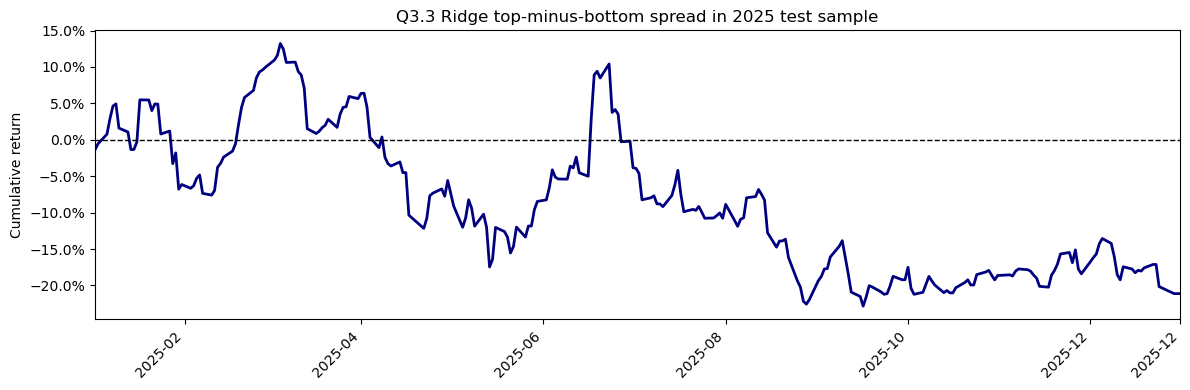

Interpretation: the model can rank contracts and define a feasible long-short spread, but near-zero out-of-sample R^2 means the evidence for a truly optimal spread is weak.


In [16]:
def summarize_return_strategy(name, daily_ret):
    daily_ret = daily_ret.dropna()
    if daily_ret.empty:
        return {
            "strategy": name,
            "n_days": 0,
            "cumulative_return": np.nan,
            "annualized_return": np.nan,
            "annualized_vol": np.nan,
            "annualized_sharpe": np.nan,
            "t_stat": np.nan,
            "hit_rate": np.nan,
            "max_drawdown": np.nan,
        }

    wealth = (1 + daily_ret).cumprod()
    drawdown = wealth / wealth.cummax() - 1
    mean_ret = daily_ret.mean()
    std_ret = daily_ret.std(ddof=1)
    return {
        "strategy": name,
        "n_days": len(daily_ret),
        "cumulative_return": wealth.iloc[-1] - 1,
        "annualized_return": wealth.iloc[-1] ** (252 / len(daily_ret)) - 1,
        "annualized_vol": np.sqrt(252) * std_ret if std_ret > 0 else np.nan,
        "annualized_sharpe": np.sqrt(252) * mean_ret / std_ret if std_ret > 0 else np.nan,
        "t_stat": mean_ret / (std_ret / np.sqrt(len(daily_ret))) if std_ret > 0 else np.nan,
        "hit_rate": (daily_ret > 0).mean(),
        "max_drawdown": drawdown.min(),
    }

q33_test_panel = q32_panel[q32_panel["sample"] == "test"].copy()
q33_ranked = q33_test_panel.sort_values(["Date", "ridge_pred", "ID"]).reset_index(drop=True)

q33_short = (
    q33_ranked.groupby("Date").head(1)[["Date", "ID", "ridge_pred", target_col_q3]]
    .rename(columns={"ID": "short_contract", "ridge_pred": "short_pred", target_col_q3: "short_ret"})
)
q33_long = (
    q33_ranked.groupby("Date").tail(1)[["Date", "ID", "ridge_pred", target_col_q3]]
    .rename(columns={"ID": "long_contract", "ridge_pred": "long_pred", target_col_q3: "long_ret"})
)

q33_daily = q33_long.merge(q33_short, on="Date", how="inner").sort_values("Date").reset_index(drop=True)
q33_daily["predicted_edge"] = q33_daily["long_pred"] - q33_daily["short_pred"]
q33_daily["realized_edge"] = q33_daily["long_ret"] - q33_daily["short_ret"]
q33_daily["spread_ret"] = 0.5 * q33_daily["realized_edge"]
q33_daily["wealth_index"] = (1 + q33_daily["spread_ret"]).cumprod()
q33_daily["cum_return"] = q33_daily["wealth_index"] - 1

q33_leg_switch = (
    q33_daily["long_contract"].ne(q33_daily["long_contract"].shift())
    | q33_daily["short_contract"].ne(q33_daily["short_contract"].shift())
)
q33_switch_rate = q33_leg_switch.iloc[1:].mean() if len(q33_daily) > 1 else np.nan

q33_summary = pd.DataFrame([{
    **summarize_return_strategy("Ridge top-minus-bottom spread", q33_daily["spread_ret"]),
    "mean_predicted_edge": q33_daily["predicted_edge"].mean(),
    "mean_realized_edge": q33_daily["realized_edge"].mean(),
    "leg_switch_rate": q33_switch_rate,
}])

q33_leg_counts = (
    pd.DataFrame({
        "long_days": q33_daily["long_contract"].value_counts(),
        "short_days": q33_daily["short_contract"].value_counts(),
    })
    .fillna(0)
    .astype(int)
    .rename_axis("contract")
    .reset_index()
    .sort_values("contract")
    .reset_index(drop=True)
)

display(q33_summary.round(6))
display(q33_leg_counts)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(q33_daily["Date"], q33_daily["cum_return"], linewidth=2, color="navy")
ax.axhline(0.0, color="black", linewidth=1, linestyle="--")
ax.set_title("Q3.3 Ridge top-minus-bottom spread in 2025 test sample")
ax.set_ylabel("Cumulative return")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
format_date_axis(ax, q33_daily["Date"].min(), q33_daily["Date"].max(), freq="2MS")
plt.tight_layout()
plt.show()

print(
    "Interpretation: the model can rank contracts and define a feasible long-short spread, "
    "but near-zero out-of-sample R^2 means the evidence for a truly optimal spread is weak."
)


## Question 4.2

In [17]:
from math import erf, exp, log, sqrt

def norm_cdf(x):
    return 0.5 * (1.0 + erf(x / sqrt(2.0)))

def black76_call(F, K, T, r, sigma):
    d1 = (log(F / K) + 0.5 * sigma ** 2 * T) / (sigma * sqrt(T))
    d2 = d1 - sigma * sqrt(T)
    return exp(-r * T) * (F * norm_cdf(d1) - K * norm_cdf(d2))

def black76_call_delta(F, K, T, r, sigma):
    d1 = (log(F / K) + 0.5 * sigma ** 2 * T) / (sigma * sqrt(T))
    return exp(-r * T) * norm_cdf(d1)

q42_valuation_date = pd.Timestamp("2026-02-27")
q42_expiry_date = pd.Timestamp("2026-03-31")
q42_symbol = "EEX DEB APR-2026"
q42_strike = 70.0
q42_rate = 0.02

q42_underlying = (
    df[df["SymbolKey"] == q42_symbol]
    .sort_values("Date")
    .reset_index(drop=True)
    .copy()
)

q42_F0 = float(q42_underlying.loc[q42_underlying["Date"] == q42_valuation_date, "Price"].iloc[0])
q42_contract_size = int(q42_underlying.loc[q42_underlying["Date"] == q42_valuation_date, "ContractSize"].iloc[0])
q42_T = (q42_expiry_date - q42_valuation_date).days / 365

# Use a short-horizon realized volatility estimate from the same April-2026 contract.
q42_clean_ret = q42_underlying.loc[q42_underlying["Date"] <= q42_valuation_date, "ret"].astype(float)
q42_clean_ret = q42_clean_ret[q42_clean_ret.abs() < 1.0]
q42_sigma = float(q42_clean_ret.tail(20).std(ddof=1) * np.sqrt(252))

q42_call_price = black76_call(q42_F0, q42_strike, q42_T, q42_rate, q42_sigma)
q42_call_delta = black76_call_delta(q42_F0, q42_strike, q42_T, q42_rate, q42_sigma)

q42_summary = pd.DataFrame([{
    "valuation_date": q42_valuation_date,
    "expiry_date": q42_expiry_date,
    "F0": q42_F0,
    "K": q42_strike,
    "T_years": q42_T,
    "r": q42_rate,
    "sigma_ann": q42_sigma,
    "call_price_per_unit": q42_call_price,
    "call_value_per_contract": q42_call_price * q42_contract_size,
    "delta": q42_call_delta,
    "delta_mwh_equivalent": q42_call_delta * q42_contract_size,
}])

display(q42_summary.round(6))
print(
    f"If we sell one call, we hedge the short delta by going long {q42_call_delta:.3f} "
    f"April futures contracts, i.e. about {q42_call_delta * q42_contract_size:.1f} MWh of exposure."
)


,valuation_date,expiry_date,F0,K,T_years,r,sigma_ann,call_price_per_unit,call_value_per_contract,delta,delta_mwh_equivalent
0,2026-02-27,2026-03-31,73.67,70.0,0.087671,0.02,0.352484,5.166502,3719.881556,0.704785,507.445346


If we sell one call, we hedge the short delta by going long 0.705 April futures contracts, i.e. about 507.4 MWh of exposure.


## Question 4.3

,h_star,delta_closed,delta_numerical,delta_abs_error,gamma_closed,gamma_numerical,gamma_abs_error
0,0.01,0.704785,0.704785,6.260000e-08,0.044725,0.044725,3.100000e-09


,h,delta_rel_error,gamma_rel_error,combined_rel_error
0,0.00001,1.000000e-10,6.868782e-04,6.868783e-04
1,0.00010,1.000000e-10,2.160710e-05,2.160720e-05
2,0.00100,9.000000e-10,1.795000e-07,1.803000e-07
3,0.01000,8.890000e-08,6.960000e-08,1.585000e-07
4,0.05000,2.222100e-06,1.814800e-06,4.036900e-06
5,0.10000,8.888200e-06,7.259900e-06,1.614820e-05
6,0.20000,3.555030e-05,2.904010e-05,6.459040e-05
7,0.50000,2.220774e-04,1.815191e-04,4.035965e-04
8,1.00000,8.867097e-04,7.263366e-04,1.613046e-03


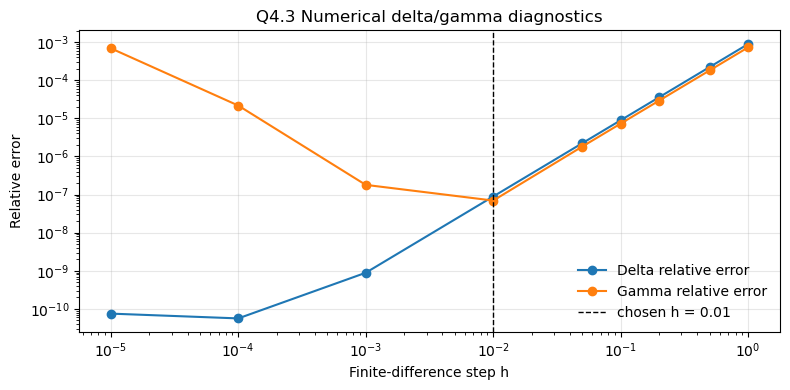

Central differences with h = 0.01 reproduce the closed-form Greeks very closely: delta error = 6.26e-08, gamma error = 3.11e-09.


In [18]:
def norm_pdf(x):
    return exp(-0.5 * x ** 2) / sqrt(2.0 * np.pi)

def black76_call_gamma(F, K, T, r, sigma):
    d1 = (log(F / K) + 0.5 * sigma ** 2 * T) / (sigma * sqrt(T))
    return exp(-r * T) * norm_pdf(d1) / (F * sigma * sqrt(T))

def central_difference_delta(price_fn, F, h, *args):
    return (price_fn(F + h, *args) - price_fn(F - h, *args)) / (2.0 * h)

def central_difference_gamma(price_fn, F, h, *args):
    return (price_fn(F + h, *args) - 2.0 * price_fn(F, *args) + price_fn(F - h, *args)) / (h ** 2)

q43_delta_closed = black76_call_delta(q42_F0, q42_strike, q42_T, q42_rate, q42_sigma)
q43_gamma_closed = black76_call_gamma(q42_F0, q42_strike, q42_T, q42_rate, q42_sigma)

q43_h_grid = np.array([1e-5, 1e-4, 1e-3, 1e-2, 5e-2, 1e-1, 2e-1, 5e-1, 1.0])
q43_rows = []

for h in q43_h_grid:
    delta_num = central_difference_delta(black76_call, q42_F0, h, q42_strike, q42_T, q42_rate, q42_sigma)
    gamma_num = central_difference_gamma(black76_call, q42_F0, h, q42_strike, q42_T, q42_rate, q42_sigma)
    q43_rows.append({
        "h": h,
        "delta_num": delta_num,
        "gamma_num": gamma_num,
        "delta_abs_error": abs(delta_num - q43_delta_closed),
        "gamma_abs_error": abs(gamma_num - q43_gamma_closed),
        "delta_rel_error": abs(delta_num - q43_delta_closed) / abs(q43_delta_closed),
        "gamma_rel_error": abs(gamma_num - q43_gamma_closed) / abs(q43_gamma_closed),
    })

q43_diag = pd.DataFrame(q43_rows)
q43_diag["combined_rel_error"] = q43_diag["delta_rel_error"] + q43_diag["gamma_rel_error"]
q43_h_star = float(q43_diag.loc[q43_diag["combined_rel_error"].idxmin(), "h"])

q43_delta_num = central_difference_delta(black76_call, q42_F0, q43_h_star, q42_strike, q42_T, q42_rate, q42_sigma)
q43_gamma_num = central_difference_gamma(black76_call, q42_F0, q43_h_star, q42_strike, q42_T, q42_rate, q42_sigma)

q43_summary = pd.DataFrame([{
    "h_star": q43_h_star,
    "delta_closed": q43_delta_closed,
    "delta_numerical": q43_delta_num,
    "delta_abs_error": abs(q43_delta_num - q43_delta_closed),
    "gamma_closed": q43_gamma_closed,
    "gamma_numerical": q43_gamma_num,
    "gamma_abs_error": abs(q43_gamma_num - q43_gamma_closed),
}])

display(q43_summary.round(10))
display(q43_diag[["h", "delta_rel_error", "gamma_rel_error", "combined_rel_error"]].round(10))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(q43_diag["h"], q43_diag["delta_rel_error"], marker="o", label="Delta relative error")
ax.plot(q43_diag["h"], q43_diag["gamma_rel_error"], marker="o", label="Gamma relative error")
ax.axvline(q43_h_star, color="black", linestyle="--", linewidth=1, label=f"chosen h = {q43_h_star:g}")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Finite-difference step h")
ax.set_ylabel("Relative error")
ax.set_title("Q4.3 Numerical delta/gamma diagnostics")
ax.grid(alpha=0.3)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print(
    f"Central differences with h = {q43_h_star:g} reproduce the closed-form Greeks very closely: "
    f"delta error = {abs(q43_delta_num - q43_delta_closed):.2e}, "
    f"gamma error = {abs(q43_gamma_num - q43_gamma_closed):.2e}."
)


## Question 4.4

In [19]:
# Assignment text says "Monday, March 3", but in the dataset the relevant close is Tuesday, 2026-03-03.
# We keep the initial sale price from Q4.2, but reprice on later dates with updated realized volatility.

q44_dates = pd.to_datetime(["2026-02-27", "2026-03-02", "2026-03-03"])

def realized_vol_from_symbol(symbol_df, end_date, window=20):
    prices = (
        symbol_df.loc[symbol_df["Date"] <= end_date, ["Date", "Price"]]
        .sort_values("Date")["Price"]
        .astype(float)
    )
    rets = prices.pct_change().dropna()
    return float(rets.tail(window).std(ddof=1) * np.sqrt(252))

q44_path = (
    df[df["SymbolKey"] == q42_symbol]
    .loc[lambda d: d["Date"].isin(q44_dates), ["Date", "ID", "SymbolKey", "Price", "ContractSize"]]
    .sort_values("Date")
    .reset_index(drop=True)
    .copy()
)

q44_path["T_years"] = (q42_expiry_date - q44_path["Date"]).dt.days / 365
q44_path["sigma_ann"] = q44_path["Date"].apply(
    lambda d: q42_sigma if d == q42_valuation_date else realized_vol_from_symbol(q42_underlying, d)
)
q44_path["option_price_per_unit"] = q44_path.apply(
    lambda row: black76_call(row["Price"], q42_strike, row["T_years"], q42_rate, row["sigma_ann"]),
    axis=1,
)
q44_path["delta_num"] = q44_path.apply(
    lambda row: central_difference_delta(
        black76_call,
        row["Price"],
        q43_h_star,
        q42_strike,
        row["T_years"],
        q42_rate,
        row["sigma_ann"],
    ),
    axis=1,
)
q44_F0 = float(q44_path.loc[q44_path["Date"] == pd.Timestamp("2026-02-27"), "Price"].iloc[0])
q44_F3 = float(q44_path.loc[q44_path["Date"] == pd.Timestamp("2026-03-03"), "Price"].iloc[0])

q44_C0 = float(q44_path.loc[q44_path["Date"] == pd.Timestamp("2026-02-27"), "option_price_per_unit"].iloc[0])
q44_C3 = float(q44_path.loc[q44_path["Date"] == pd.Timestamp("2026-03-03"), "option_price_per_unit"].iloc[0])
q44_delta0 = float(q44_path.loc[q44_path["Date"] == pd.Timestamp("2026-02-27"), "delta_num"].iloc[0])

q44_dF = q44_F3 - q44_F0
q44_gamma0 = q43_gamma_num

q44_option_pnl = (q44_C0 - q44_C3) * q42_contract_size
q44_static_futures_pnl = q44_delta0 * q44_dF * q42_contract_size
q44_gamma_correction_pnl = 0.5 * q44_gamma0 * q44_dF ** 2 * q42_contract_size

q44_summary = pd.DataFrame([
    {
        "strategy": "Short call only",
        "option_pnl": q44_option_pnl,
        "futures_pnl": 0.0,
        "total_pnl": q44_option_pnl,
    },
    {
        "strategy": "Short call + static delta hedge",
        "option_pnl": q44_option_pnl,
        "futures_pnl": q44_static_futures_pnl,
        "total_pnl": q44_option_pnl + q44_static_futures_pnl,
    },
    {
        "strategy": "Short call + delta-gamma approximation",
        "option_pnl": q44_option_pnl,
        "futures_pnl": q44_static_futures_pnl + q44_gamma_correction_pnl,
        "total_pnl": q44_option_pnl + q44_static_futures_pnl + q44_gamma_correction_pnl,
    },
])

display(q44_path[["Date", "ID", "SymbolKey", "Price", "T_years", "sigma_ann", "option_price_per_unit", "delta_num"]].round(6))
display(q44_summary.round(2))


,Date,ID,SymbolKey,Price,T_years,sigma_ann,option_price_per_unit,delta_num
0,2026-02-27,EEXFM2,EEX DEB APR-2026,73.67,0.087671,0.352484,5.166502,0.704785
1,2026-03-02,EEXFM1,EEX DEB APR-2026,88.20,0.079452,0.794628,19.542966,0.872263
2,2026-03-03,EEXFM1,EEX DEB APR-2026,100.60,0.076712,0.924436,31.307345,0.937318


,strategy,option_pnl,futures_pnl,total_pnl
0,Short call only,-18821.41,0.00,-18821.41
1,Short call + static delta hedge,-18821.41,13665.50,-5155.91
2,Short call + delta-gamma approximation,-18821.41,25342.24,6520.83
